In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import kruskal

In [57]:
df_video_features = pd.read_csv("../data/video_features.csv")

## Important: Per participant normalization

In [58]:
# -------------------------
# 1. Load participant mapping
# -------------------------
df_participants = pd.read_csv("../data/pilot.csv")

df_participants = df_participants[["clue_id", "Spymaster ID"]].rename(
    columns={"Spymaster ID": "participant_id"}
)

# -------------------------
# 2. Merge
# -------------------------
df = df_video_features.merge(df_participants, on="clue_id", how="left")

# -------------------------
# 3. Ensure clue_id matches (optional but safe)
# -------------------------
df["clue_id"] = df["clue_id"].astype(str).str.strip()
df["participant_id"] = df["participant_id"].astype(str).str.strip()

# -------------------------
# 4. Select ONLY numeric features
# -------------------------
exclude_cols = ["clue_id", "participant_id", "confidence", "difficulty"]

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features = [col for col in numeric_cols if col not in exclude_cols]

print(f"Using {len(features)} numeric features")

# -------------------------
# 5. Add deviation features
# -------------------------
for col in features:
    df[f"{col}_dev"] = df[col] - df.groupby("participant_id")[col].transform("mean")

# -------------------------
# 6. Safe z-score normalization
# -------------------------
def safe_zscore(x):
    std = x.std()
    if std == 0 or np.isnan(std):
        return x - x.mean()
    return (x - x.mean()) / std

df[features] = df.groupby("participant_id")[features].transform(safe_zscore)

# -------------------------
# 7. Fill NaNs
# -------------------------
df = df.fillna(0)

print("Done. Shape:", df.shape)

Using 5 numeric features
Done. Shape: (72, 14)


In [59]:
df.columns

Index(['clue_id', 'confidence', 'difficulty', 'neutral_ratio',
       'positive_ratio', 'negative_ratio', 'mean_head_movement',
       'look_away_ratio', 'participant_id', 'neutral_ratio_dev',
       'positive_ratio_dev', 'negative_ratio_dev', 'mean_head_movement_dev',
       'look_away_ratio_dev'],
      dtype='str')

## Map confidence & difficulty levels to 3 classes

In [60]:
def map_levels(x):
    if x in [1, 2]:
        return "low"
    elif x == 3:
        return "medium"
    elif x in [4, 5]:
        return "high"

In [61]:
df["confidence_level"] = df["confidence"].apply(map_levels)
df["difficulty_level"] = df["difficulty"].apply(map_levels)

## Inspect Box Plots

In [62]:
exclude_cols = ["clue_id", "participant_id", "confidence", "difficulty", "confidence_level", "difficulty_level"]
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features = [col for col in numeric_cols if col not in exclude_cols]

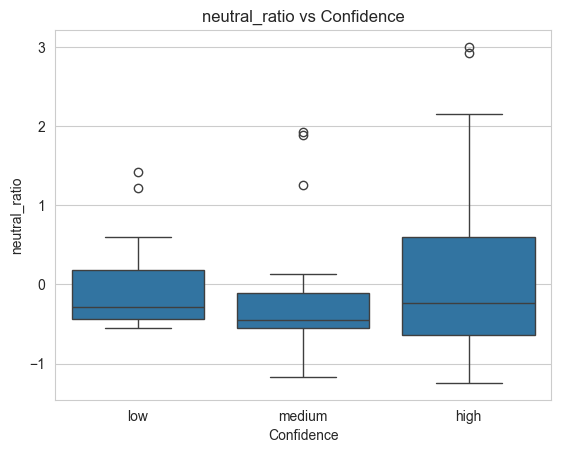

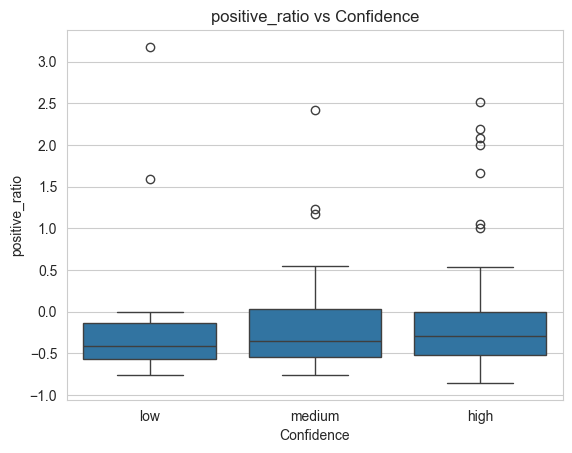

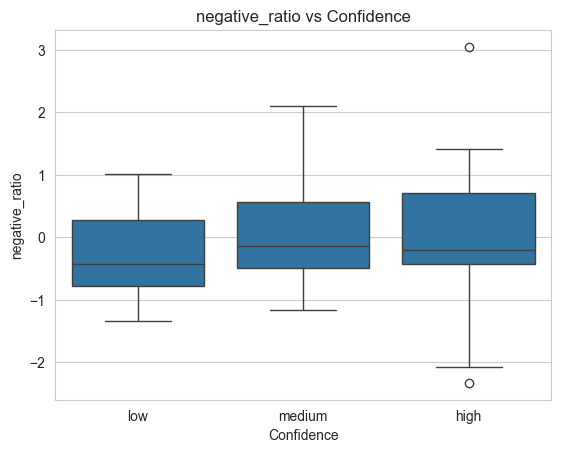

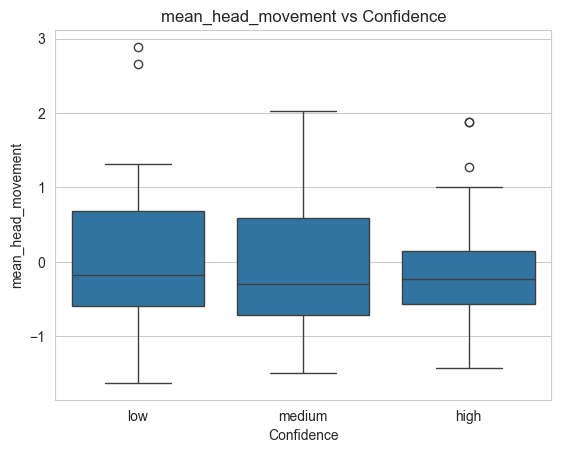

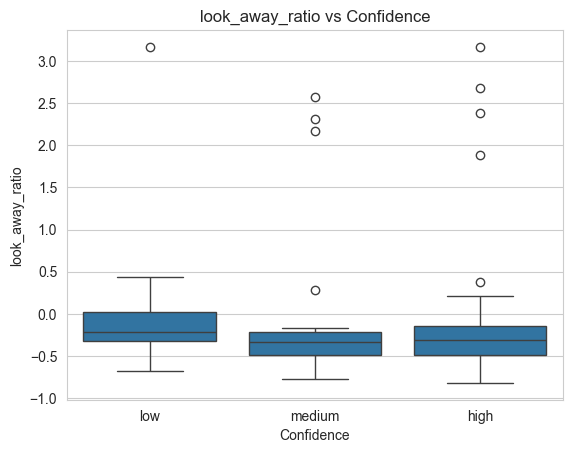

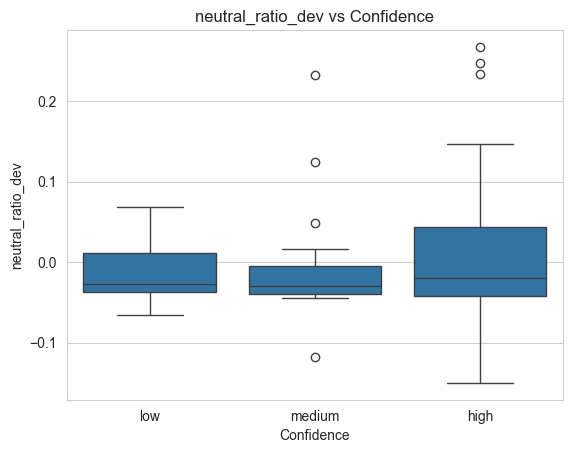

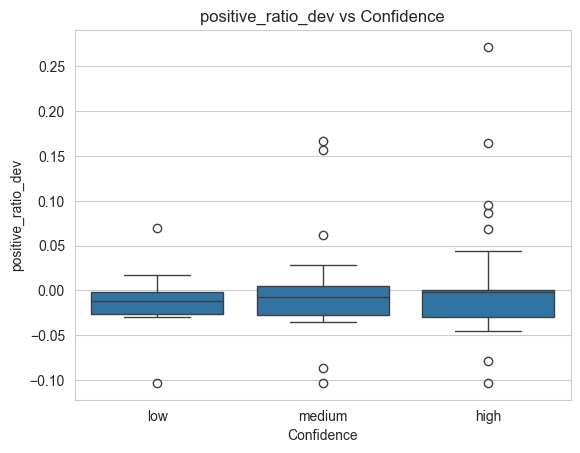

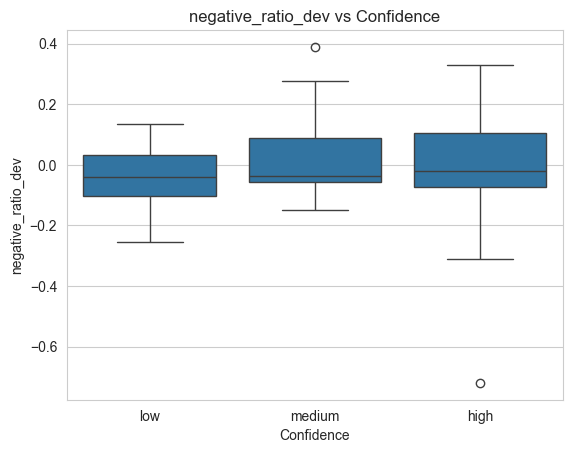

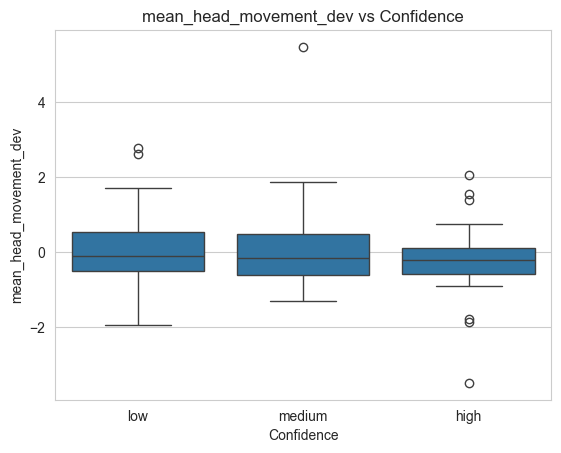

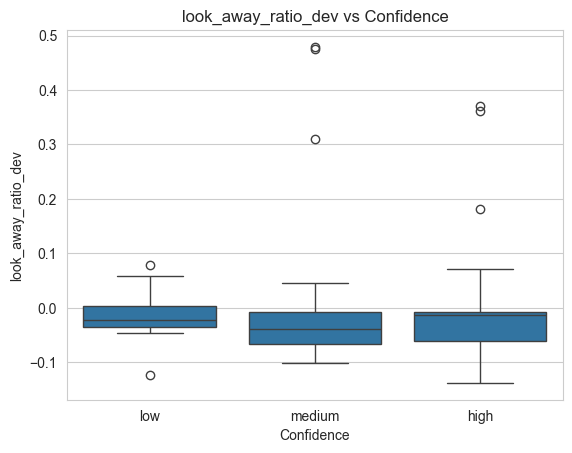

In [63]:
for feature in features:
    plt.figure()
    sns.boxplot(x="confidence_level", y=feature, data=df, order = ["low", "medium", "high"])
    plt.title(f"{feature} vs Confidence")
    plt.xlabel("Confidence")
    plt.ylabel(feature)
    plt.show()

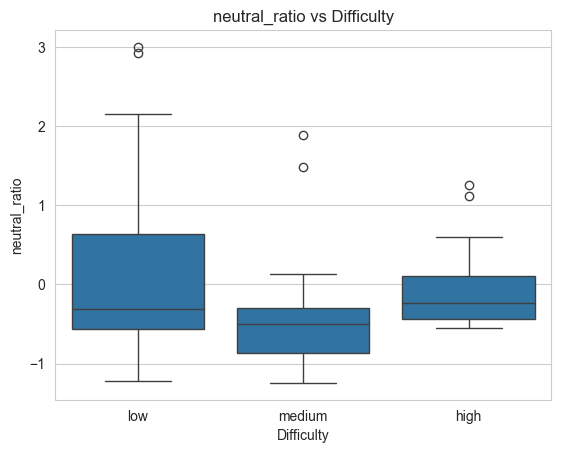

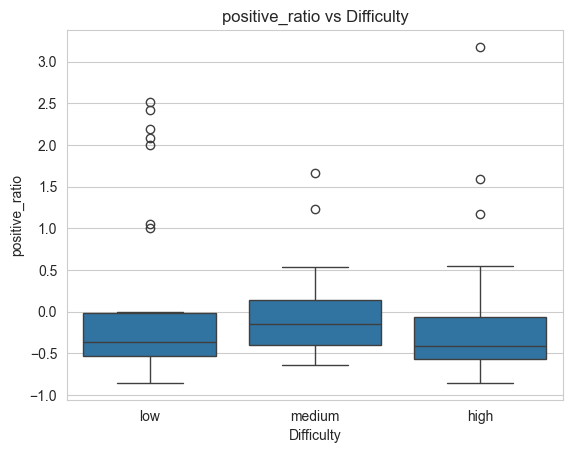

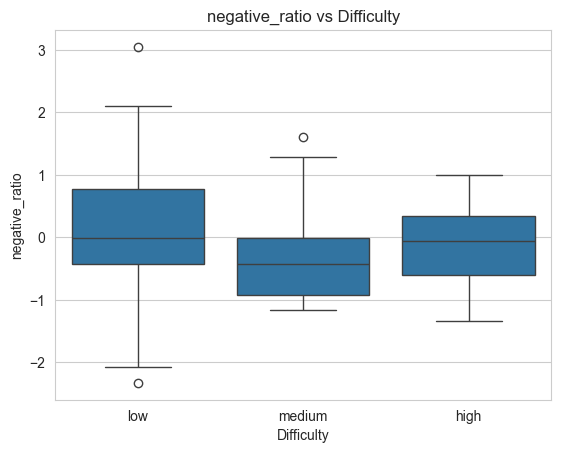

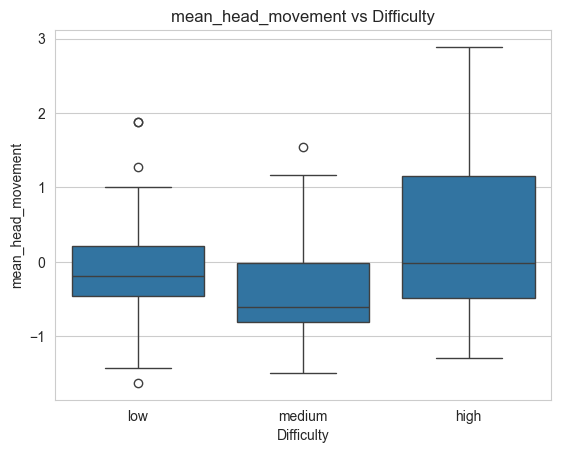

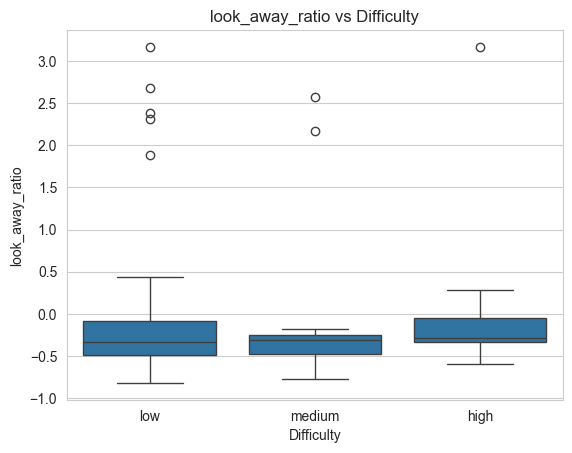

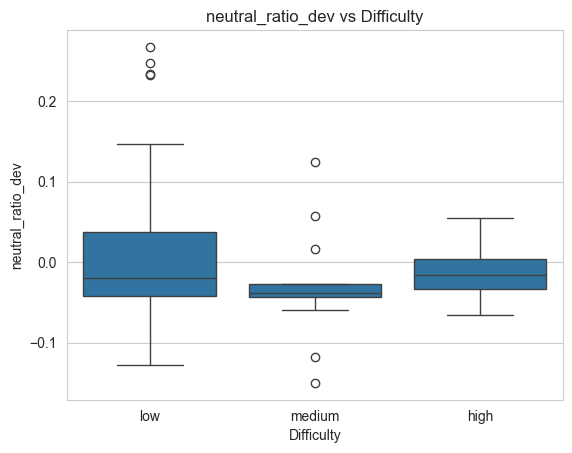

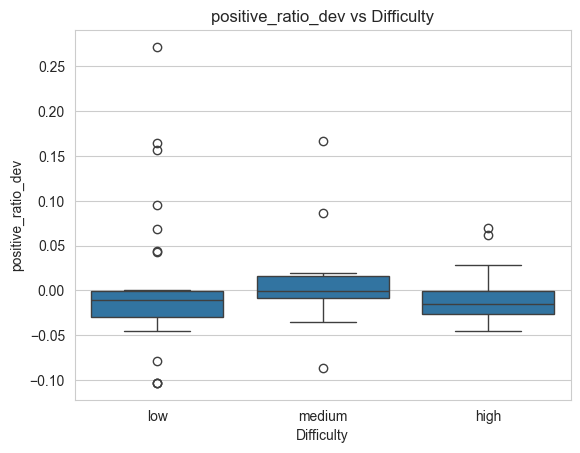

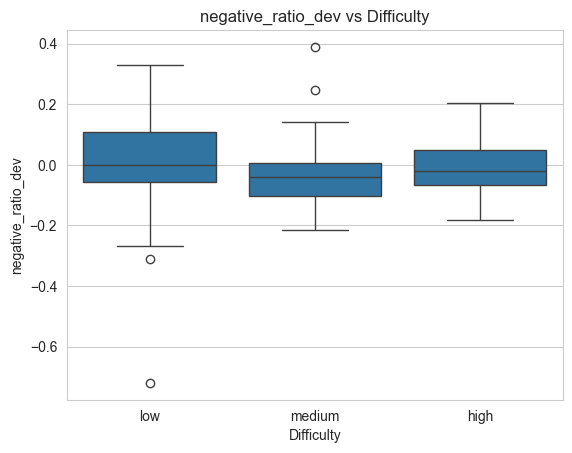

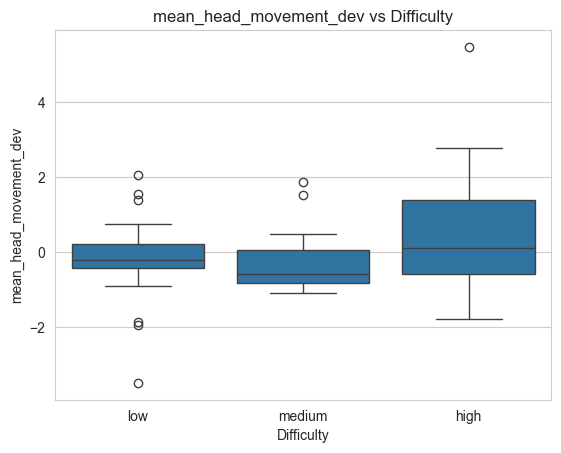

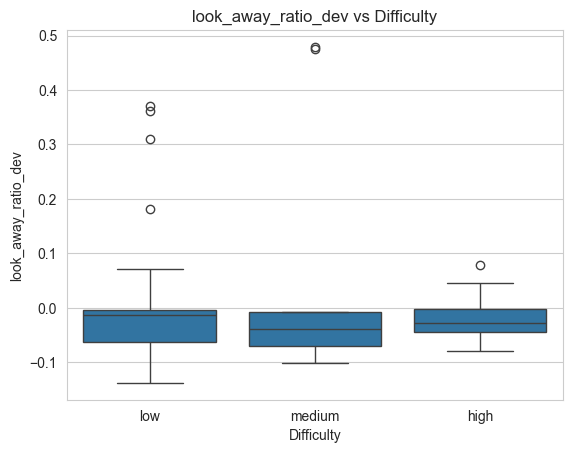

In [64]:
for feature in features:
    plt.figure()
    sns.boxplot(x="difficulty_level", y=feature, data=df, order = ["low", "medium", "high"])
    plt.title(f"{feature} vs Difficulty")
    plt.xlabel("Difficulty")
    plt.ylabel(feature)
    plt.show()

## Statistical Significance 

In [65]:
for feature in features:
    groups = [group[feature].dropna().values 
              for _, group in df.groupby("confidence_level")]

    stat, p = kruskal(*groups)
    print(f"{feature}: p={p:.4f}")

neutral_ratio: p=0.4963
positive_ratio: p=0.8928
negative_ratio: p=0.6386
mean_head_movement: p=0.9235
look_away_ratio: p=0.1630
neutral_ratio_dev: p=0.9013
positive_ratio_dev: p=0.8892
negative_ratio_dev: p=0.5129
mean_head_movement_dev: p=0.5729
look_away_ratio_dev: p=0.5291


In [66]:
for feature in features:
    groups = [group[feature].dropna().values 
              for _, group in df.groupby("difficulty_level")]

    stat, p = kruskal(*groups)
    print(f"{feature}: p={p:.4f}")

neutral_ratio: p=0.1394
positive_ratio: p=0.3895
negative_ratio: p=0.2099
mean_head_movement: p=0.0935
look_away_ratio: p=0.3604
neutral_ratio_dev: p=0.2875
positive_ratio_dev: p=0.2078
negative_ratio_dev: p=0.4125
mean_head_movement_dev: p=0.2108
look_away_ratio_dev: p=0.6981


In [68]:
# -------------------------
# Setup
# -------------------------
targets = ["confidence_level", "difficulty_level"]
alpha = 0.05

results = []

# -------------------------
# Loop over targets + features
# -------------------------
for target in targets:
    
    # drop rows with missing target
    df_clean = df[df[target].notna()]
    
    for feature in features:
        # print(f"Testing {feature} vs {target}...")
        
        # skip if feature is empty
        if df_clean[feature].notna().sum() == 0:
            # print(f"Skipping {feature} for {target} - no data")
            continue
        
        # collect groups
        groups = [
            group[feature].dropna().values
            for name, group in df_clean.groupby(target)
            if len(group) > 1
        ]
        
        # need at least 2 groups
        if len(groups) < 2:
            # print(f"Skipping {feature} for {target} - not enough groups: {len(groups)}")
            continue
        
        try:
            stat, p = kruskal(*groups)
            print(f"{feature} vs {target}: p={p:.4f}")
            results.append({
                "target": target,
                "feature": feature,
                "p_value": p,
                "significant": p < alpha
            })
        
        except Exception as e:
            print(f"Error testing {feature} vs {target}: {e}")
            continue

# -------------------------
# Results dataframe
# -------------------------
results_df = pd.DataFrame(results)

# sort by significance
results_df = results_df.sort_values("p_value")

# show significant ones
significant = results_df[results_df["significant"]]

print("Significant features:")
print(significant.head(20))

print(f"\nTotal significant: {len(significant)}")

neutral_ratio vs confidence_level: p=0.4963
positive_ratio vs confidence_level: p=0.8928
negative_ratio vs confidence_level: p=0.6386
mean_head_movement vs confidence_level: p=0.9235
look_away_ratio vs confidence_level: p=0.1630
neutral_ratio_dev vs confidence_level: p=0.9013
positive_ratio_dev vs confidence_level: p=0.8892
negative_ratio_dev vs confidence_level: p=0.5129
mean_head_movement_dev vs confidence_level: p=0.5729
look_away_ratio_dev vs confidence_level: p=0.5291
neutral_ratio vs difficulty_level: p=0.1394
positive_ratio vs difficulty_level: p=0.3895
negative_ratio vs difficulty_level: p=0.2099
mean_head_movement vs difficulty_level: p=0.0935
look_away_ratio vs difficulty_level: p=0.3604
neutral_ratio_dev vs difficulty_level: p=0.2875
positive_ratio_dev vs difficulty_level: p=0.2078
negative_ratio_dev vs difficulty_level: p=0.4125
mean_head_movement_dev vs difficulty_level: p=0.2108
look_away_ratio_dev vs difficulty_level: p=0.6981
Significant features:
Empty DataFrame
Column

## Correlations

In [69]:
def map_levels(x):
    if x == "low":
        return 0
    elif x == "medium":
        return 0.5
    elif x == "high":
        return 1
df["confidence_level"] = df["confidence_level"].apply(map_levels)
df["difficulty_level"] = df["difficulty_level"].apply(map_levels)
df.head()

,clue_id,confidence,difficulty,neutral_ratio,positive_ratio,negative_ratio,mean_head_movement,look_away_ratio,participant_id,neutral_ratio_dev,positive_ratio_dev,negative_ratio_dev,mean_head_movement_dev,look_away_ratio_dev,confidence_level,difficulty_level
0,1,3,2,-0.460501,-0.288675,-0.422476,-0.449992,-0.315584,2,-0.038046,-0.001562,-0.040580,-0.431549,-0.007749,0.5,0.0
1,2,4,1,2.997761,-0.288675,3.047818,0.619986,-0.315584,2,0.247669,-0.001562,0.292753,0.594576,-0.007749,1.0,0.0
2,3,4,2,0.211939,-0.288675,-0.422476,-0.233130,-0.315584,2,0.017510,-0.001562,-0.040580,-0.223575,-0.007749,1.0,0.0
3,4,2,4,-0.460501,-0.288675,-0.422476,-0.700174,-0.315584,2,-0.038046,-0.001562,-0.040580,-0.671478,-0.007749,0.0,1.0
4,5,4,3,-0.460501,-0.288675,-0.254558,-0.564544,-0.315584,2,-0.038046,-0.001562,-0.024451,-0.541406,-0.007749,1.0,0.5


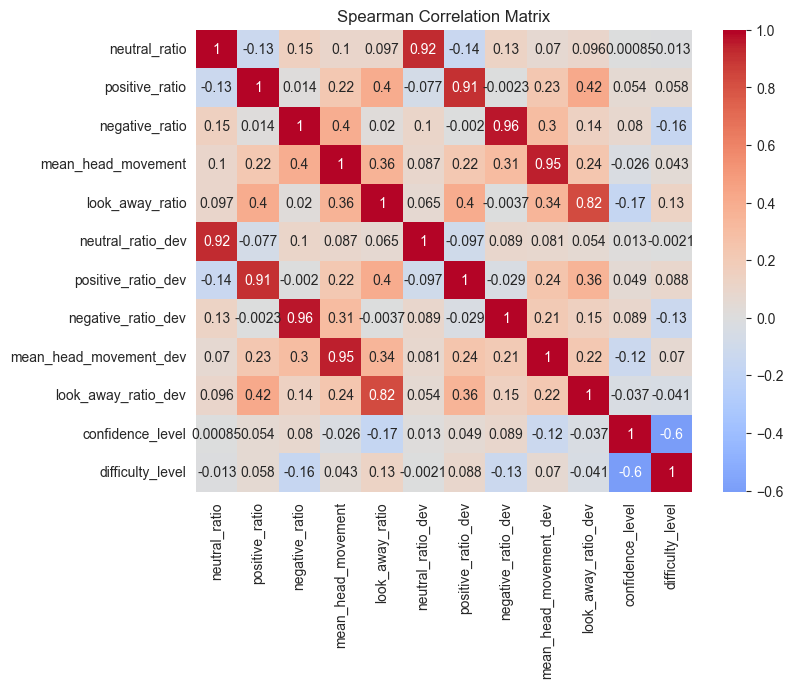

In [70]:
corr_matrix = df[features + ["confidence_level", "difficulty_level"]].corr(method="spearman")

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix")
plt.show()

In [71]:
# Step 2: Compute Spearman correlation for all features + targets
corr_matrix = df[features + ["confidence_level", "difficulty_level"]].corr(method="spearman")

# Step 3: Select correlations for the target columns as Series
confidence_corr = corr_matrix["confidence_level"].drop(labels="confidence_level")
difficulty_corr = corr_matrix["difficulty_level"].drop(labels="difficulty_level")

# Step 4: Filter features with strong correlation (>0.5 absolute value)
top_confidence_features = confidence_corr[confidence_corr.abs() > 0.5].sort_values(ascending=False)
top_difficulty_features = difficulty_corr[difficulty_corr.abs() > 0.5].sort_values(ascending=False)

# Step 5: Display top 20
print("Top features correlated with confidence_level (>0.5):")
print(top_confidence_features.head(20))

print("\nTop features correlated with difficulty_level (>0.5):")
print(top_difficulty_features.head(20))

Top features correlated with confidence_level (>0.5):
difficulty_level   -0.604255
Name: confidence_level, dtype: float64

Top features correlated with difficulty_level (>0.5):
confidence_level   -0.604255
Name: difficulty_level, dtype: float64
